# Chapter 15 laboratory: neural warm starts for belief propagation

The goal is deliberately modest: **do not replace belief propagation**. Instead, learn an initialization for the BP cavity fields and then return to the exact classical update.

For an Ising model

$$
p(x)\propto \exp\left(\sum_{(i,j)}J_{ij}x_ix_j+\sum_i h_i x_i\right), \qquad x_i\in\{-1,+1\},
$$

we parameterize directed BP messages by cavity fields $u_{i\to j}$. The neural network sees the model parameters and predicts a vector of cavity fields. Classical BP then iterates until the usual fixed-point residual is below a specified tolerance.

This experiment tests the **warm-start / bootstrapping** use of neuralization: training changes the cost of reaching a fixed point, not the fixed-point equations themselves.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error

FIGDIR = Path("figs")
FIGDIR.mkdir(exist_ok=True)
plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 19,
})
rng = np.random.default_rng(11)

L=3
nodes=list(range(L*L))
edges=[]
for r in range(L):
    for c in range(L):
        i=r*L+c
        if c+1<L: edges.append((i,i+1))
        if r+1<L: edges.append((i,i+L))
directed=[(i,j) for i,j in edges for (i,j) in [(i,j),(j,i)]]
dir_index={e:k for k,e in enumerate(directed)}
neigh={i:[] for i in nodes}
for i,j in edges:
    neigh[i].append(j); neigh[j].append(i)

def bp_fixed_point(h,Jvals,init=None,tol=1e-9,maxiter=1000,damping=0.55):
    J={tuple(sorted(e)):v for e,v in zip(edges,Jvals)}
    u=np.zeros(len(directed)) if init is None else np.array(init,dtype=float).copy()
    for it in range(maxiter):
        new=np.empty_like(u)
        for q,(i,j) in enumerate(directed):
            H=h[i] + sum(u[dir_index[(k,i)]] for k in neigh[i] if k!=j)
            z=np.tanh(J[tuple(sorted((i,j)))])*np.tanh(H)
            z=np.clip(z,-1+1e-13,1-1e-13)
            new[q]=np.arctanh(z)
        upd=(1-damping)*u+damping*new
        res=np.max(np.abs(upd-u))
        u=upd
        if res<tol:
            return u,it+1,res
    return u,maxiter,res

def bp_beliefs_and_logz(h,Jvals,u):
    J={tuple(sorted(e)):v for e,v in zip(edges,Jvals)}
    bi={}
    for i in nodes:
        H=h[i]+sum(u[dir_index[(k,i)]] for k in neigh[i])
        pplus=1/(1+np.exp(-2*H))
        bi[i]=np.array([1-pplus,pplus])  # states -1,+1
    bij={}
    states=np.array([-1,1])
    for e,(i,j) in enumerate(edges):
        Hij=h[i]+sum(u[dir_index[(k,i)]] for k in neigh[i] if k!=j)
        Hji=h[j]+sum(u[dir_index[(k,j)]] for k in neigh[j] if k!=i)
        W=np.exp(Jvals[e]*np.outer(states,states)+Hij*states[:,None]+Hji*states[None,:])
        bij[(i,j)]=W/W.sum()
    # Bethe free energy using unary and edge factors
    F=0.0
    for e,(i,j) in enumerate(edges):
        b=bij[(i,j)]
        logpsi=Jvals[e]*np.outer(states,states)
        F += np.sum(b*(np.log(b+1e-300)-logpsi))
    for i in nodes:
        b=bi[i]
        logpsi=h[i]*states
        F += (1-len(neigh[i]))*np.sum(b*(np.log(b+1e-300)-logpsi))
    return bi,bij,-F

def exact_logz(h,Jvals):
    X=np.array(np.meshgrid(*([[-1,1]]*len(nodes)), indexing='ij')).reshape(len(nodes),-1).T
    energy=X@h
    for val,(i,j) in zip(Jvals,edges): energy += val*X[:,i]*X[:,j]
    m=energy.max()
    return m+np.log(np.exp(energy-m).sum())

def make_instances(n,jlo,jhi,hscale=0.20):
    H=rng.normal(0,hscale,size=(n,len(nodes)))
    J=rng.uniform(jlo,jhi,size=(n,len(edges)))
    return H,J


## 1. Generate exact BP labels on a fixed graph

A $3\times3$ grid has 9 spins, 12 undirected edges, and 24 directed cavity messages. We train on moderate attractive couplings, where damped BP is stable.

In [2]:
Htr,Jtr=make_instances(700,0.08,0.42)
Hte,Jte=make_instances(220,0.08,0.42)
Hood,Jood=make_instances(220,0.44,0.68)

def solve_batch(H,J):
    targets=[]; iters=[]
    for h,j in zip(H,J):
        u,it,res=bp_fixed_point(h,j)
        targets.append(u); iters.append(it)
    return np.array(targets),np.array(iters)

Utr,_=solve_batch(Htr,Jtr)
Ute,base_te=solve_batch(Hte,Jte)
Uood,base_ood=solve_batch(Hood,Jood)
Xtr=np.hstack([Htr,Jtr]); Xte=np.hstack([Hte,Jte]); Xood=np.hstack([Hood,Jood])
print("training target shape:",Utr.shape)
print("median zero-start iterations, test:",np.median(base_te))
print("median zero-start iterations, stronger-coupling transfer:",np.median(base_ood))

training target shape: (700, 24)
median zero-start iterations, test: 41.0
median zero-start iterations, stronger-coupling transfer: 138.5


## 2. Learn the cavity-field initializer

The network is intentionally small. The point is not to optimize architecture; it is to test whether repeated related inference problems contain enough regularity to amortize part of the fixed-point search.

In [3]:
model=make_pipeline(StandardScaler(),MLPRegressor(hidden_layer_sizes=(96,96),activation="tanh",max_iter=550,random_state=1,early_stopping=True,validation_fraction=0.12))
model.fit(Xtr,Utr)
Up_te=model.predict(Xte); Up_ood=model.predict(Xood)

def corrected_iters(H,J,Uinit):
    its=[]; final_gap=[]
    for h,j,u0 in zip(H,J,Uinit):
        u,it,res=bp_fixed_point(h,j,init=u0)
        its.append(it); final_gap.append(res)
    return np.array(its),np.array(final_gap)

warm_te,res_te=corrected_iters(Hte,Jte,Up_te)
warm_ood,res_ood=corrected_iters(Hood,Jood,Up_ood)
print("test: median iterations zero/warm",np.median(base_te),np.median(warm_te))
print("OOD:  median iterations zero/warm",np.median(base_ood),np.median(warm_ood))
print("initial message MAE test",np.mean(np.abs(Up_te-Ute)))
print("initial message MAE OOD ",np.mean(np.abs(Up_ood-Uood)))

test: median iterations zero/warm 41.0 38.0
OOD:  median iterations zero/warm 138.5 137.0
initial message MAE test 0.018932607792630354
initial message MAE OOD  0.15588455232355686


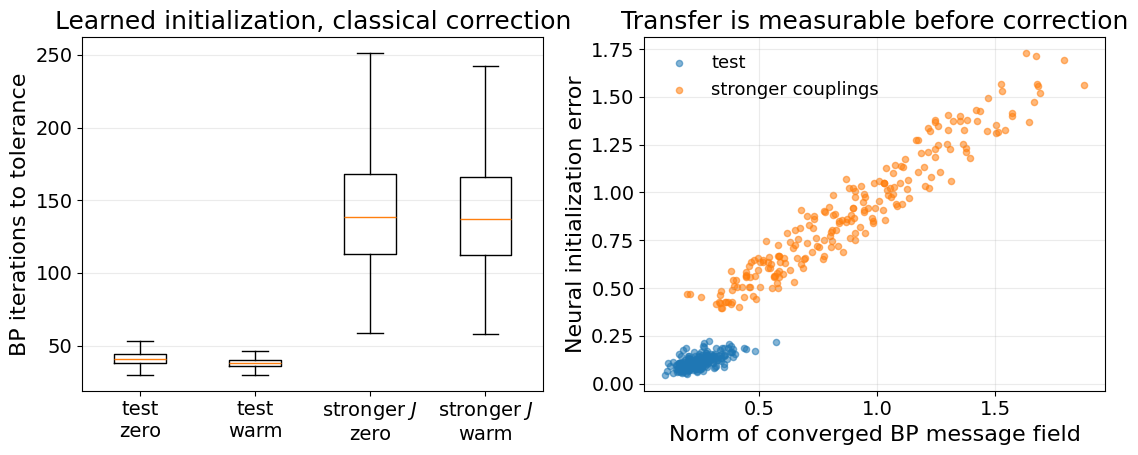

In [4]:
fig,axes=plt.subplots(1,2,figsize=(11.4,4.8))
labels=["test\nzero","test\nwarm","stronger $J$\nzero","stronger $J$\nwarm"]
data=[base_te,warm_te,base_ood,warm_ood]
axes[0].boxplot(data,tick_labels=labels,showfliers=False)
axes[0].set_ylabel("BP iterations to tolerance")
axes[0].set_title("Learned initialization, classical correction")
axes[0].grid(axis="y",alpha=0.25)

axes[1].scatter(np.linalg.norm(Ute,axis=1),np.linalg.norm(Up_te-Ute,axis=1),s=20,alpha=0.55,label="test")
axes[1].scatter(np.linalg.norm(Uood,axis=1),np.linalg.norm(Up_ood-Uood,axis=1),s=20,alpha=0.55,label="stronger couplings")
axes[1].set_xlabel("Norm of converged BP message field")
axes[1].set_ylabel("Neural initialization error")
axes[1].set_title("Transfer is measurable before correction")
axes[1].legend(frameon=False)
axes[1].grid(alpha=0.25)
fig.tight_layout()
fig.savefig(FIGDIR/"ch15_01_bp_warm_start.pdf",bbox_inches="tight")
fig.savefig(FIGDIR/"ch15_01_bp_warm_start.png",dpi=220,bbox_inches="tight")
plt.show()

## Interpretation

The learned initializer is useful only if it reduces the work of the classical solver. A small neural message error is not itself the objective. The strongest diagnostic is that after neural prediction the ordinary BP residual can still be evaluated and driven to tolerance.

The out-of-distribution experiment is equally important. If the learned initializer becomes poor at stronger couplings, the classical BP correction does not silently accept the error; it exposes it through additional iterations or nonconvergence.

## Exercises

1. Train the same architecture to predict singleton magnetizations directly. Compare its transfer error with the warm-start construction.
2. Add damping as a learned scalar predicted from the instance. Does predicting the algorithmic hyperparameter transfer better than predicting all cavity fields?
3. Train on $3\times3$ grids and test a graph-local message network on a different topology. Why can the dense MLP used here not do this without redesign?
4. **Challenge:** use the learned prediction only when its initial BP residual is below a threshold; otherwise fall back to a neutral initialization. Measure the speed/reliability tradeoff.